## **<span style="color:red">i. Outlier Detection & Removal</span>**

<br>

#### **<span style="color:black">- Dataset</span>**

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()     # After Outlier Removal 3556
df.shape

(3675, 21)

In [12]:
df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7585.0,1081.0,3,2,2,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8600.0,1105.0,2,2,2,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sector 86,0.46,79.0,58228.0,2,2,1,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,semifurnished,Low Floor,Low


<br>

#### **<span style="color:black">1. Price</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

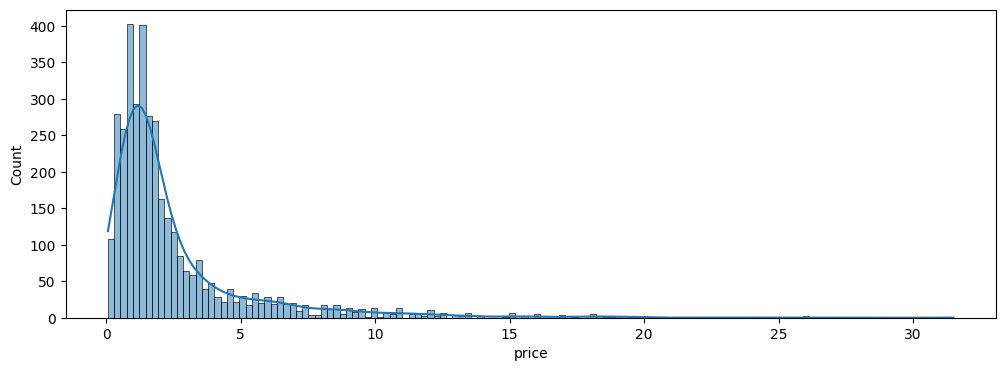

In [19]:
# outliers on the basis of price column
plt.figure(figsize=(12, 4)) 
sns.histplot(df['price'], kde=True)
plt.show()

<Axes: xlabel='price'>

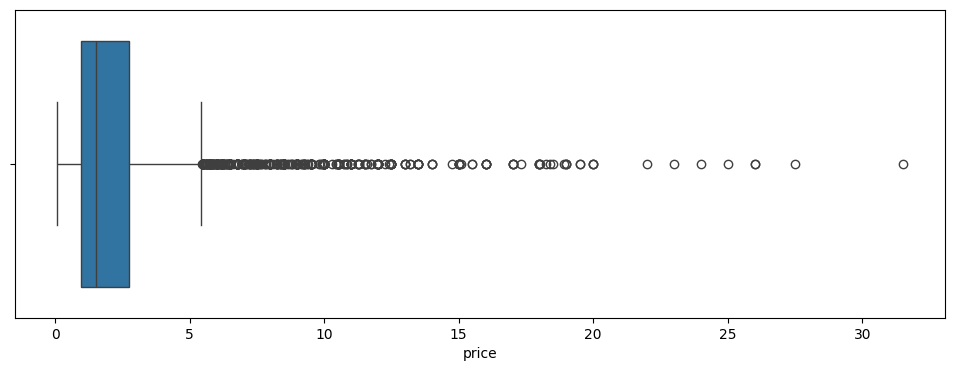

In [21]:
plt.figure(figsize=(12, 4)) 
sns.boxplot(x=df['price'])

In [31]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_price_stats = outliers['price'].describe()

outliers_price_stats

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

<br>

##### **<span style="color:black">ii. Outlier Analysis</span>**

In [34]:
outliers.sort_values('price',ascending=False).head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
821,house,sector 26,31.5,35000.0,9000.0,7,9,3+,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,unfurnished,Mid Floor,Medium
2834,house,sector 43,27.5,24366.0,11286.0,6,7,3+,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,furnished,Mid Floor,Low
2488,house,sector 26,26.0,57206.0,4545.0,6,7,3+,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,furnished,Low Floor,Medium


NOTE: On the basis of price col we can say that there are some genuine outliers but there are some data erros as well

<br>

#### **<span style="color:black">2. Price_per_sqft</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

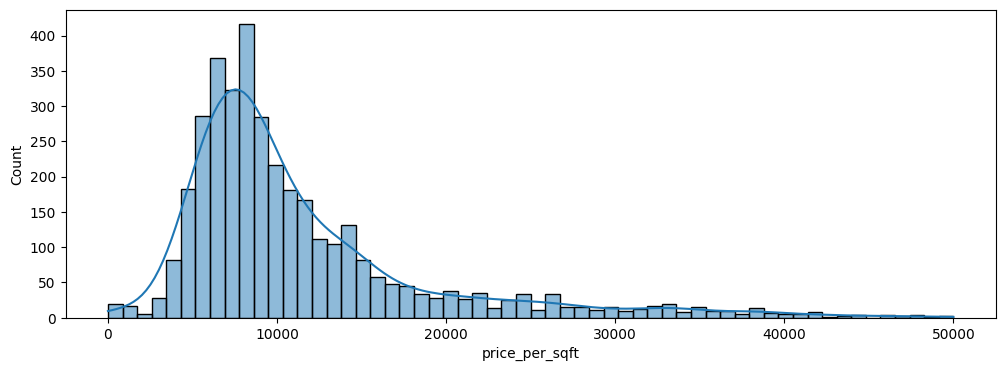

In [56]:
# outliers on the basis of price_per_sqft column
plt.figure(figsize=(12, 4)) 
sns.histplot(df['price_per_sqft'], kde=True)
plt.show()

<Axes: xlabel='price_per_sqft'>

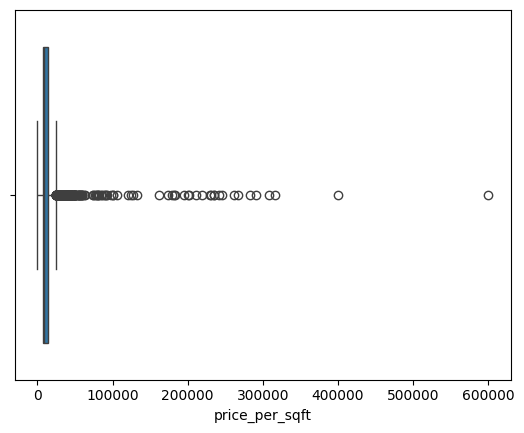

In [36]:
sns.boxplot(x=df['price_per_sqft'])

In [38]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

outliers_sqft_stats

count       354.000000
mean      52592.612994
std       61150.458507
min       24489.000000
25%       28208.250000
50%       33368.500000
75%       41982.250000
max      600000.000000
Name: price_per_sqft, dtype: float64

👉 Indicates:

- Extreme outliers
- Likely wrong area values (unit issue)

<br>

##### **<span style="color:black">ii. Data Cleaning (Fixing Fake Outliers)</span>**

<br>
👉 Fixing wrong area unit issue (sq yard → sq ft)

- Values < 1000 are assumed to be in sq. yards
- They are converted to sq. feet by multiplying by 9

In [46]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

<br>

👉 Recalculating after fixing area

In [47]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

In [48]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     28819.299435
std      13249.775635
min        514.000000
25%      25546.250000
50%      29788.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

<br>

👉 Updating the DataFrame

In [49]:
df.update(outliers_sqft)

<br>

👉 Visualization

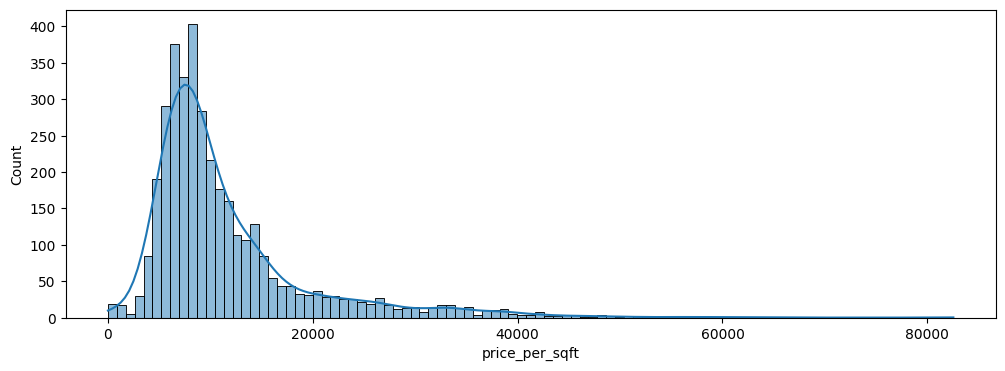

In [50]:
# outliers on the basis of price_per_sqft column
plt.figure(figsize=(12, 4)) 
sns.histplot(df['price_per_sqft'], kde=True)
plt.show()

<Axes: xlabel='price_per_sqft'>

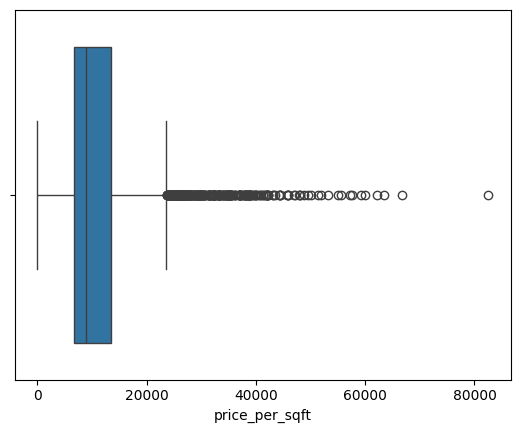

In [51]:
sns.boxplot(x=df['price_per_sqft'])

In [52]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

outliers_sqft_stats

count      315.000000
mean     32986.425397
std       8436.759530
min      23662.000000
25%      26566.000000
50%      31481.000000
75%      37037.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

Some outliers were fake (data error) → fixed

Some outliers are real (true anomalies) → still exist

| Metric        | Before Fix | After Fix | Change        |
|--------------|-----------|----------|---------------|
| Outlier Count | 354       | 315      | Reduced       |
| Max           | 600,000   | 82,540   | Large Drop    |
| Std           | 61,150    | 8,436    | Stabilized    |

<br>

##### **<span style="color:black">iii. Outlier Removal (Handling Real Outliers)</span>**

👉 Purpose:

- Manually look at very high values
- Check if they are: Real luxury properties ✅ Or still unrealistic ❌
- Apply threshold

In [45]:
df[df['price_per_sqft']>50000].head()


,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
66,house,sector 13,0.5,90909.0,495.0,12,4,3,NaN,Old Property,NaN,55.0,NaN,0,0,0,0,0,semifurnished,Mid Floor,Low
229,house,sector 12,0.6,120000.0,450.0,5,3,2,North,Moderately Old,NaN,30.0,15.0,0,0,0,0,1,semifurnished,Mid Floor,Low
336,house,sector 28,4.5,125000.0,3240.0,4,4,0,NaN,Undefined,NaN,360.0,NaN,0,0,0,0,0,semifurnished,Mid Floor,Low
342,house,sector 50,7.1,283333.0,2259.0,3,3,3,East,Moderately Old,NaN,240.0,NaN,0,1,0,0,0,semifurnished,Low Floor,Low
386,house,sohna road road,5.5,55000.0,1000.0,3,3,0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,semifurnished,Low Floor,Low


After keen analysis I will drop all properties with price_per_sqft > 50,000

In [53]:
df = df[df['price_per_sqft'] <= 50000]

<br>

##### **<span style="color:black">iv. Post Outlier Visualization & Statistics</span>**

Now I will Visualize again,  To confirm:

- Outliers are reduced
- Distribution is now cleaner

<Axes: xlabel='price_per_sqft'>

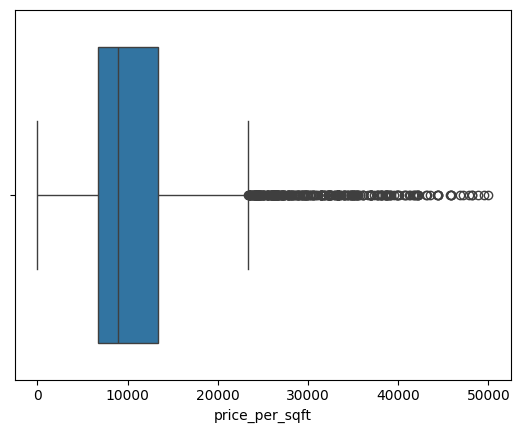

In [54]:
sns.boxplot(x=df['price_per_sqft'])

In [55]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

outliers_sqft_stats

count      310.000000
mean     31621.148387
std       6339.434531
min      23401.000000
25%      26235.000000
50%      30556.000000
75%      35491.500000
max      50000.000000
Name: price_per_sqft, dtype: float64

| Metric | Before Threshold | After Threshold | Change |
|--------|----------------|----------------|--------|
| Count  | 315            | 310            | -5 (removed) |
| Mean   | 32,986         | 31,621         | ↓ Reduced |
| Std    | 8,436          | 6,339          | ↓ More stable |
| Min    | 23,662         | 23,401         | Slight change |
| Q1     | 26,566         | 26,235         | Slight change |
| Median | 31,481         | 30,556         | Slight change |
| Q3     | 37,037         | 35,491         | Slight change |
| Max    | 82,540         | 50,000         | 🔥 Capped |

<br>

#### **<span style="color:black">3. Area</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

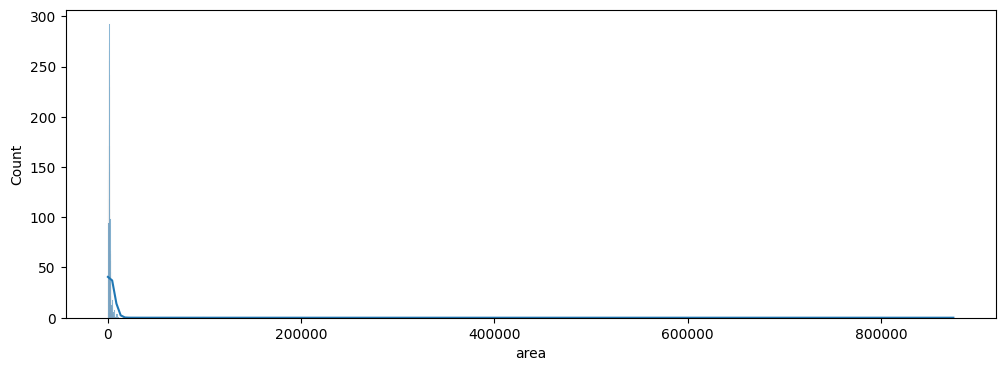

In [57]:
# outliers on the basis of area column
plt.figure(figsize=(12, 4)) 
sns.histplot(df['area'], kde=True)
plt.show()

<Axes: xlabel='area'>

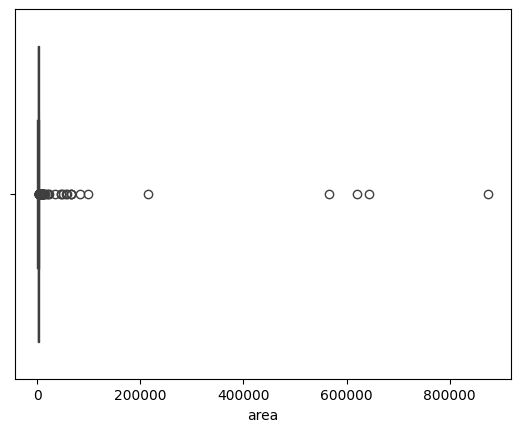

In [58]:
sns.boxplot(x=df['area'])

In [60]:
# Calculate the IQR for the 'price' column
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['area'] < lower_bound) | (df['area'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_sqft_stats = outliers_sqft['area'].describe()

outliers_sqft_stats

count       253.000000
mean      19610.181818
std       86526.254501
min        3980.000000
25%        4500.000000
50%        5018.000000
75%        6565.000000
max      875000.000000
Name: area, dtype: float64

In [59]:
df['area'].describe()

count      3645.000000
mean       2972.558299
std       23214.722040
min         145.000000
25%        1275.000000
50%        1759.000000
75%        2355.000000
max      875000.000000
Name: area, dtype: float64

<br>

##### **<span style="color:black">ii. Outlier Removal</span>**

👉 **Checking Area Greater than 1 lakh**

In [61]:
df[df['area'] > 100000]

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
1638,flat,sector 107,0.51,9.0,566667.0,2,2,1,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,semifurnished,Mid Floor,Low
1648,flat,sohna road,0.35,4.0,875000.0,2,2,2,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,unfurnished,Mid Floor,Low
2111,flat,sector 95,0.45,7.0,642857.0,2,2,2,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,semifurnished,Low Floor,Medium
2651,flat,sector 95,0.31,5.0,620000.0,2,2,1,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,semifurnished,Low Floor,Medium
3021,house,sector 50,5.00,232.0,215517.0,6,5,3+,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,furnished,Low Floor,Low


In [62]:
# Droping them
df = df[df['area'] < 100000]

<br>

👉 **Checking Area Greater than 1 lakh Checking Area Greater than 10k**

In [63]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
818,house,sector 26,18.40,1859.0,98978.0,6,8,3+,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,furnished,Mid Floor,Medium
48,house,sector 13,1.25,151.0,82781.0,10,6,2,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,semifurnished,Mid Floor,Low
1123,flat,sector 95,0.38,58.0,65517.0,3,2,1,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,semifurnished,High Floor,Medium
1796,flat,sector 95,0.38,58.0,65517.0,2,2,2,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,semifurnished,Mid Floor,Low
300,house,sector 28,13.00,1992.0,65261.0,10,10,3+,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,semifurnished,Low Floor,Low
2,flat,sector 86,0.46,79.0,58228.0,2,2,1,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,semifurnished,Low Floor,Low
2356,flat,sector 95,0.33,60.0,55000.0,2,2,1,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,semifurnished,High Floor,Low
115,flat,sohna road,0.28,57.0,49123.0,1,1,2,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,semifurnished,Low Floor,Low
2666,house,sector 25,7.30,1560.0,46795.0,9,9,2,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,furnished,Mid Floor,Medium
3649,flat,sector 95,0.24,53.0,45283.0,2,2,1,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,semifurnished,Mid Floor,Low


Droping few

In [64]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)

In [65]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
48,house,sector 13,1.25,151.0,82781.0,10,6,2,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,semifurnished,Mid Floor,Low
300,house,sector 28,13.00,1992.0,65261.0,10,10,3+,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,semifurnished,Low Floor,Low
2666,house,sector 25,7.30,1560.0,46795.0,9,9,2,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,furnished,Mid Floor,Medium
1358,house,sector 57,6.25,2778.0,22498.0,9,9,3+,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,furnished,Mid Floor,Medium
3195,house,sector 43,5.50,2716.0,20250.0,8,7,3+,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,furnished,Mid Floor,Medium
2131,flat,sector 85,2.50,1379.0,18129.0,4,5,3+,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,furnished,High Floor,Low
3088,house,sector 50,6.95,4490.0,15479.0,3,3,1,North-East,Moderately Old,NaN,2160.0,1720.00,0,1,0,0,0,semifurnished,Low Floor,High
3444,flat,sector 88a,1.75,1384.0,12645.0,3,3,3+,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,semifurnished,Mid Floor,Medium
2834,house,sector 43,27.50,24366.0,11286.0,6,7,3+,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,furnished,Mid Floor,Low
2342,flat,sector 65,13.20,12000.0,11000.0,4,4,3,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,semifurnished,High Floor,Medium


Correcting few

In [68]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

<br>

##### **<span style="color:black">iii. Post Outlier Visualization & Statistics</span>**

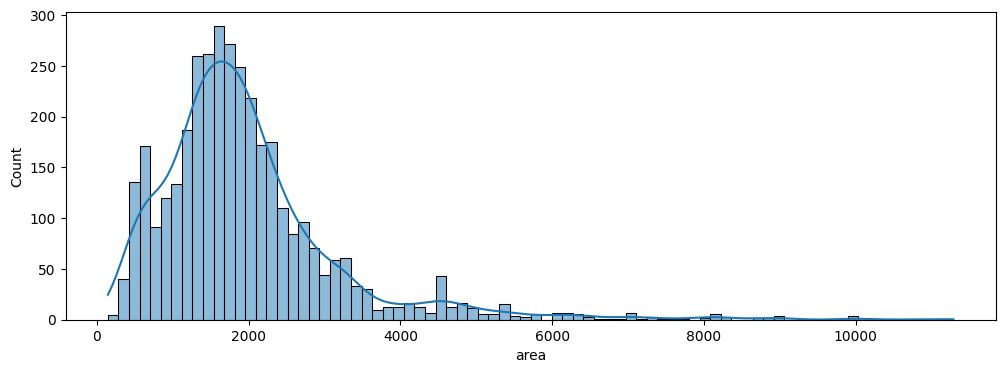

In [69]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['area'], kde=True)
plt.show()

<Axes: xlabel='area'>

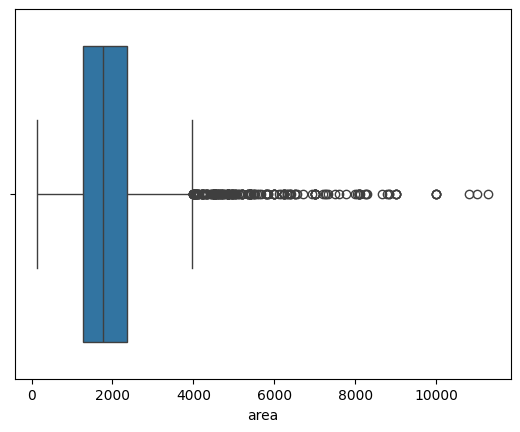

In [70]:
sns.boxplot(x=df['area'])

In [71]:
# Calculate the IQR for the 'price' column
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['area'] < lower_bound) | (df['area'] > upper_bound)]

# Displaying the number of outliers and some statistics
outliers_sqft_stats = outliers_sqft['area'].describe()

outliers_sqft_stats

count      233.000000
mean      5514.948498
std       1528.331104
min       3980.000000
25%       4500.000000
50%       4891.000000
75%       6156.000000
max      11286.000000
Name: area, dtype: float64

| Metric | Before Cleaning | After Cleaning | Change |
|--------|----------------|----------------|--------|
| Count  | 253            | 233            | -20 (removed) |
| Mean   | 19,610         | 5,515          | 🔻 Large reduction |
| Std    | 86,526         | 1,528          | 🔻 Huge stabilization |
| Min    | 3,980          | 3,980          | No change |
| Q1     | 4,500          | 4,500          | No change |
| Median | 5,018          | 4,891          | Slight reduction |
| Q3     | 6,565          | 6,156          | Slight reduction |
| Max    | 875,000        | 11,286         | 🔥 Extreme values removed |

<br>

#### **<span style="color:black">4. Bedroom</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

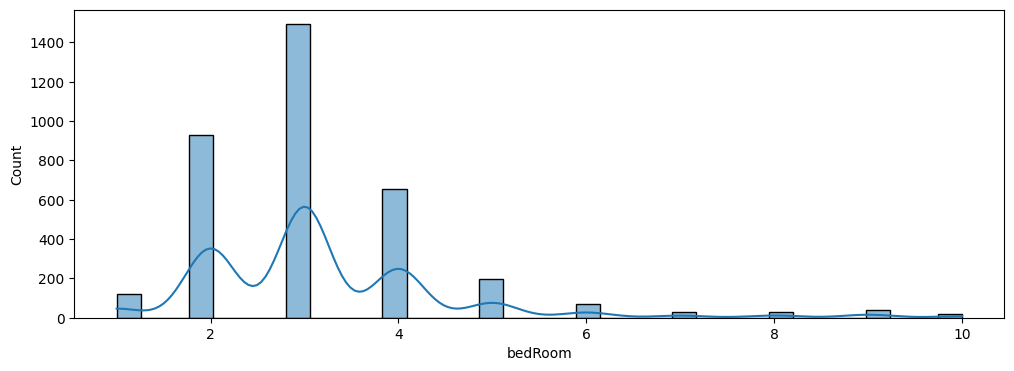

In [81]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['bedRoom'], kde=True)
plt.show()

<Axes: xlabel='bedRoom'>

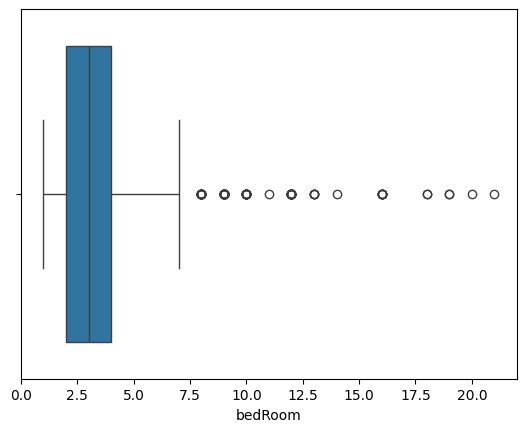

In [73]:
sns.boxplot(x=df['bedRoom'])

In [74]:
df['bedRoom'].describe()

count    3631.000000
mean        3.334619
std         1.829995
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

<br>

##### **<span style="color:black">ii. Outlier Removal</span>**

In [75]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
3618,house,sector 54,5.00,43066.0,1161.0,21,21,3+,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,unfurnished,Mid Floor,Low
2611,house,sector 43,4.50,39062.0,1152.0,20,20,3+,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,unfurnished,Mid Floor,Low
1493,house,sector 17a,3.93,24214.0,1623.0,19,17,3,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,semifurnished,Mid Floor,Medium
78,house,sector 17a,3.87,5160.0,7500.0,19,17,3+,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,semifurnished,Mid Floor,Medium
19,house,sector 54,5.50,38194.0,1440.0,18,18,3+,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,unfurnished,Mid Floor,Medium
1381,house,sector 55,7.05,46906.0,1503.0,18,18,3+,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,unfurnished,Mid Floor,Medium
2096,house,sector 26,20.00,48888.0,4091.0,16,16,3+,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,furnished,Mid Floor,Low
3457,house,sector 56,12.39,45889.0,2700.0,16,18,3+,North-East,New Property,NaN,2700.0,NaN,0,1,0,1,0,furnished,Mid Floor,Low
2137,house,sector 40,12.00,38986.0,3078.0,16,16,3+,NaN,New Property,NaN,3078.0,NaN,1,1,1,1,0,furnished,Mid Floor,Low
2039,house,sector 43,13.50,50000.0,2700.0,16,16,3+,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,semifurnished,Mid Floor,Low


In [76]:
df = df[df['bedRoom'] <= 10]

<br>

##### **<span style="color:black">iii. Post Outlier Visualization & Statistics</span>**

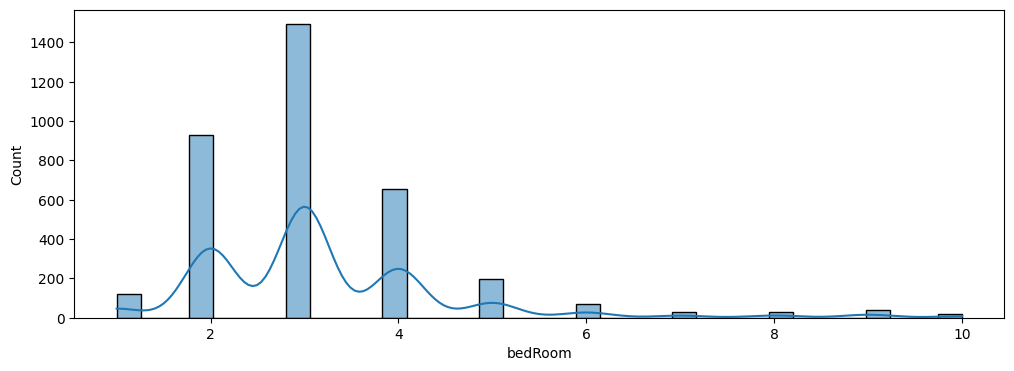

In [78]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['bedRoom'], kde=True)
plt.show()

<Axes: xlabel='bedRoom'>

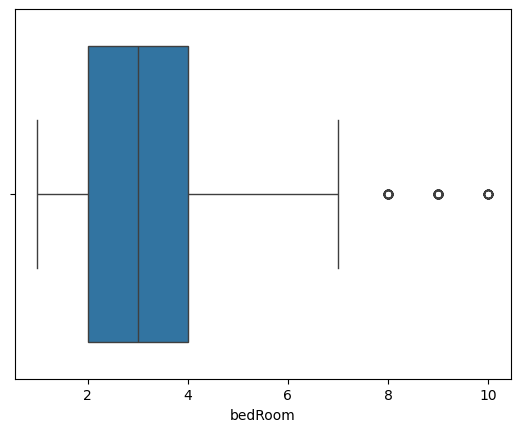

In [79]:
sns.boxplot(x=df['bedRoom'])

In [80]:
df['bedRoom'].describe()

count    3586.000000
mean        3.204685
std         1.393726
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

<br>

#### **<span style="color:black">5. Bathroom</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

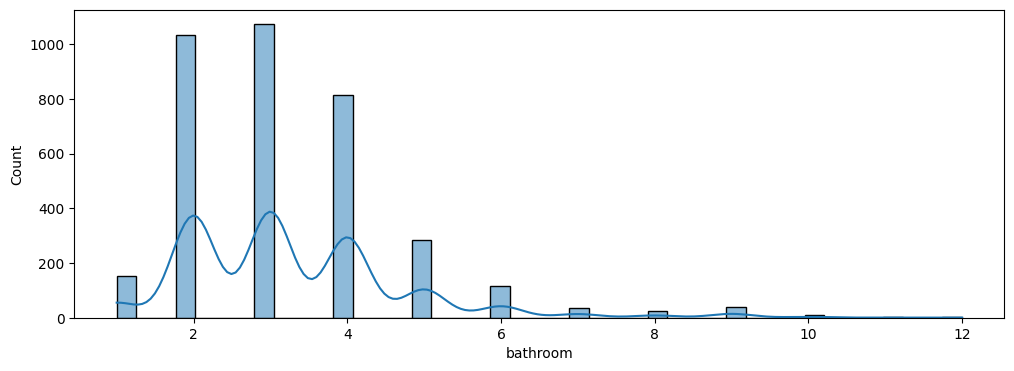

In [82]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['bathroom'], kde=True)
plt.show()

<Axes: xlabel='bathroom'>

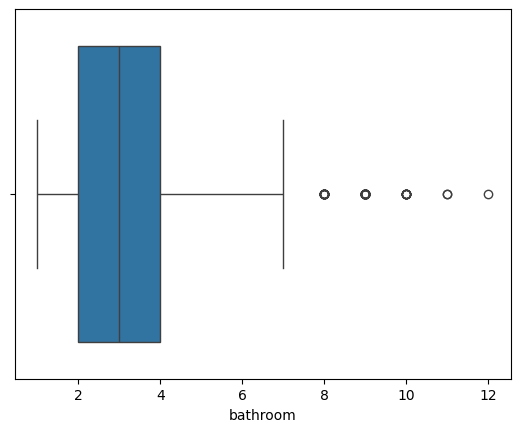

In [83]:
sns.boxplot(x=df['bathroom'])

<br>

##### **<span style="color:black">ii. Outlier Analysis</span>**

In [84]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
3267,house,sector 60,18.02,28200.0,6390.0,9,12,3+,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,furnished,Mid Floor,Medium
2771,house,sector 39,7.00,10000.0,7000.0,10,11,3+,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,furnished,Mid Floor,Low
2816,house,sector 24,11.00,28902.0,3806.0,8,11,3+,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,furnished,Mid Floor,Low


NOTE: On the basis of bathroom col we can say that there are some genuine outliers but there are some data erros as well

<br>

#### **<span style="color:black">6. super built up area</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

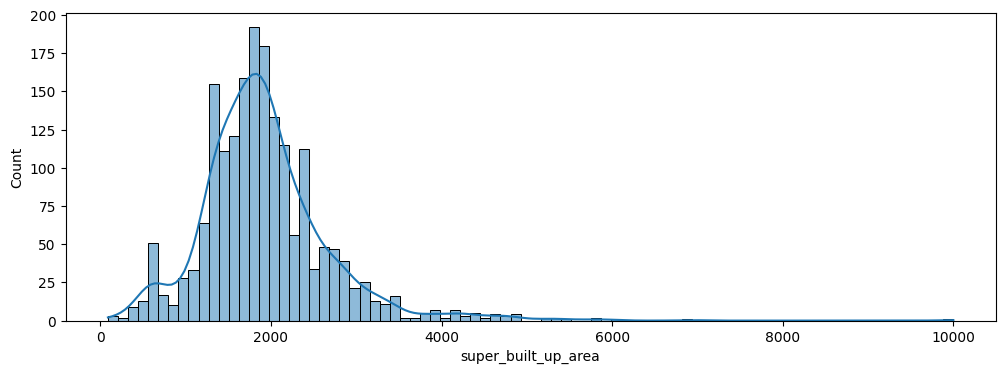

In [89]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['super_built_up_area'], kde=True)
plt.show()

<Axes: xlabel='super_built_up_area'>

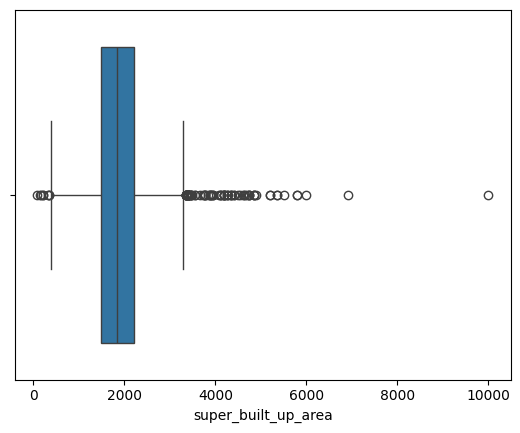

In [86]:
sns.boxplot(x=df['super_built_up_area'])

In [87]:
df['super_built_up_area'].describe()

count     1874.000000
mean      1925.872759
std        763.880964
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<br>

##### **<span style="color:black">ii. Outlier Analysis</span>**

In [88]:
df[df['super_built_up_area'] > 6000]

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
1323,flat,sector 81,4.7,6786.0,6926.0,4,4,3+,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,furnished,High Floor,Medium
3265,flat,gwal pahari,7.5,7500.0,10000.0,5,6,3+,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,semifurnished,High Floor,Low


<br>

#### **<span style="color:black">7. built up area</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

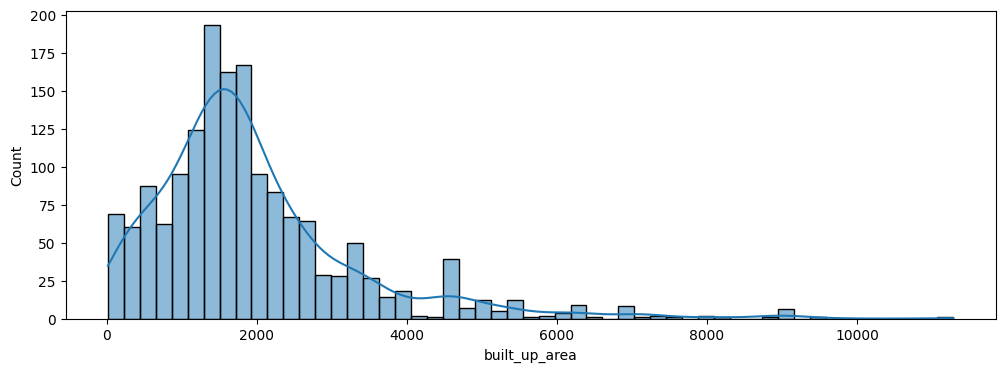

In [90]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['built_up_area'], kde=True)
plt.show()

<Axes: xlabel='built_up_area'>

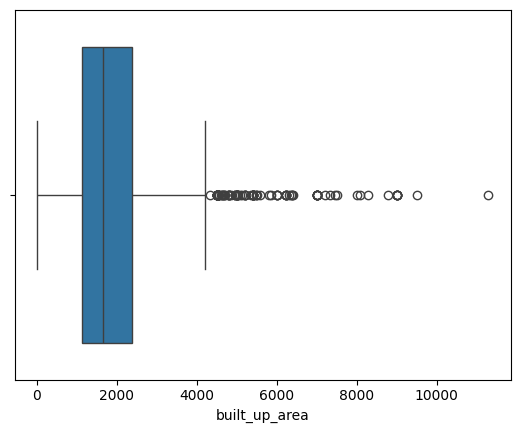

In [91]:
sns.boxplot(x=df['built_up_area'])

<br>

##### **<span style="color:black">ii. Outlier Analysis</span>**

In [92]:
df[df['built_up_area'] > 10000]

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
2834,house,sector 43,27.5,24366.0,11286.0,6,7,3+,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,furnished,Mid Floor,Low


<br>

#### **<span style="color:black">8. carpet area</span>**

<br>

##### **<span style="color:black">i. Basic Analysis</span>**

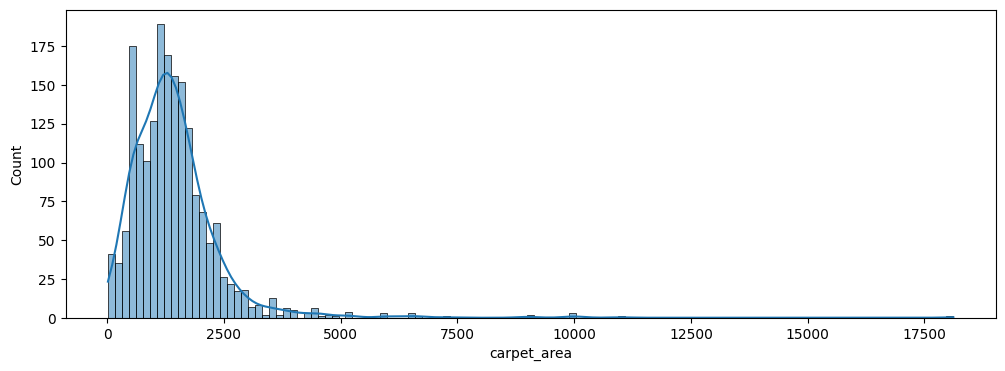

In [93]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['carpet_area'], kde=True)
plt.show()

<Axes: xlabel='carpet_area'>

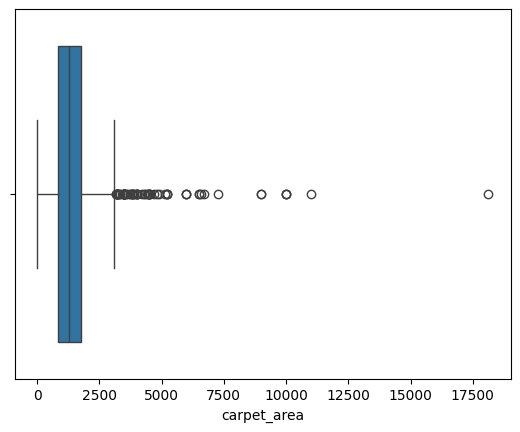

In [94]:
sns.boxplot(x=df['carpet_area'])

<br>

##### **<span style="color:black">ii. Outlier Analysis</span>**

In [95]:
df[df['carpet_area'] > 10000]

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
2131,flat,sector 85,2.5,1379.0,1812.0,4,5,3+,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,1,1,furnished,High Floor,Low
2342,flat,sector 65,13.2,12000.0,11000.0,4,4,3,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,semifurnished,High Floor,Medium


In [96]:
df.loc[2131,'carpet_area'] = 1812

<br>

##### **<span style="color:black">iii. Post Outlier Visualization & Statistics</span>**

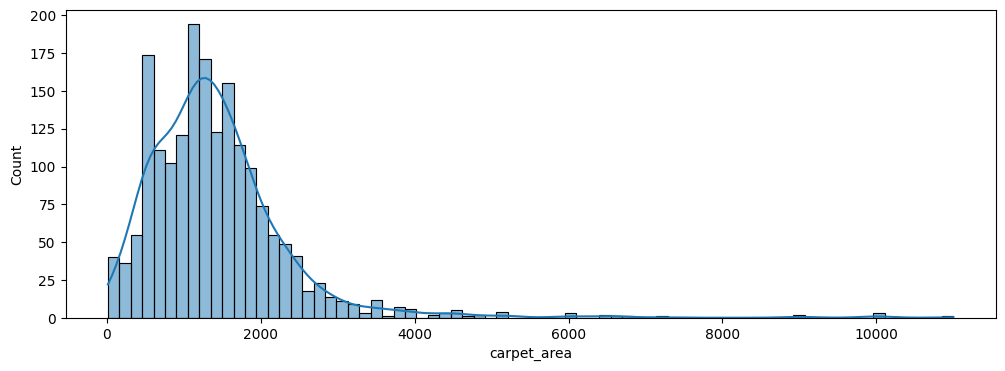

In [98]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['carpet_area'], kde=True)
plt.show()

<Axes: xlabel='carpet_area'>

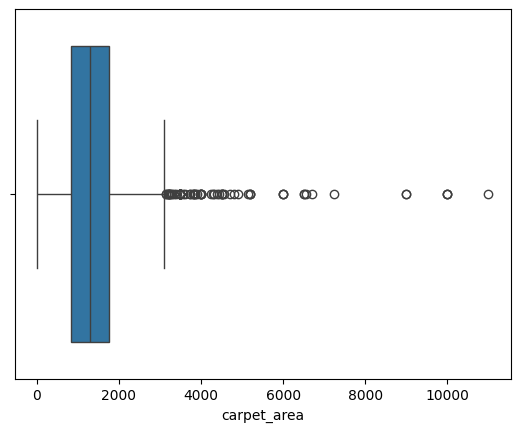

In [99]:
sns.boxplot(x=df['carpet_area'])

<br>

#### **<span style="color:black">- We will calculate the 'price_per_sqft' feature again</span>**

because we have done a lot of tranformation, correct it

In [102]:
df.head()

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7585.0,1081.0,3,2,2,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8600.0,1105.0,2,2,2,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low
3,flat,sohna road,0.32,5470.0,585.0,2,2,1,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,semifurnished,High Floor,Low
4,flat,sector 92,1.60,8020.0,1995.0,3,4,3+,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,furnished,Mid Floor,High
5,flat,sector 102,0.48,9022.0,532.0,2,2,1,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,semifurnished,Mid Floor,High


In [103]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [104]:
df.head()

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7586.0,1081.0,3,2,2,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8597.0,1105.0,2,2,2,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low
3,flat,sohna road,0.32,5470.0,585.0,2,2,1,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,semifurnished,High Floor,Low
4,flat,sector 92,1.60,8020.0,1995.0,3,4,3+,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,furnished,Mid Floor,High
5,flat,sector 102,0.48,9023.0,532.0,2,2,1,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,semifurnished,Mid Floor,High


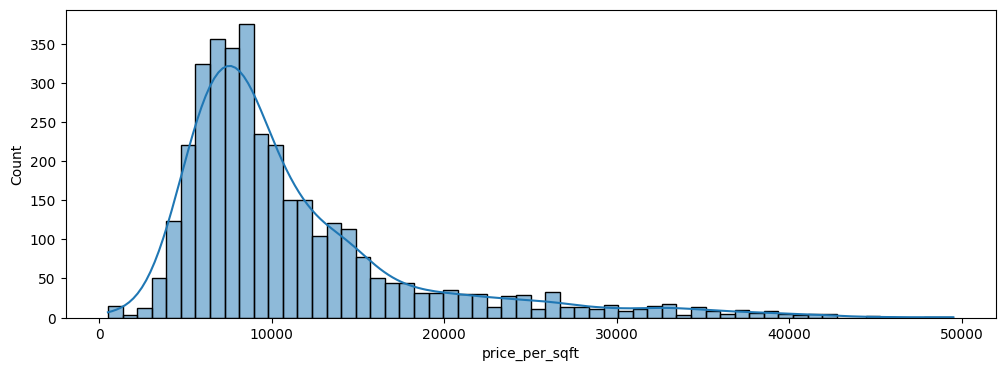

In [105]:
plt.figure(figsize=(12, 4)) 
sns.histplot(df['price_per_sqft'], kde=True)
plt.show()

<Axes: ylabel='price_per_sqft'>

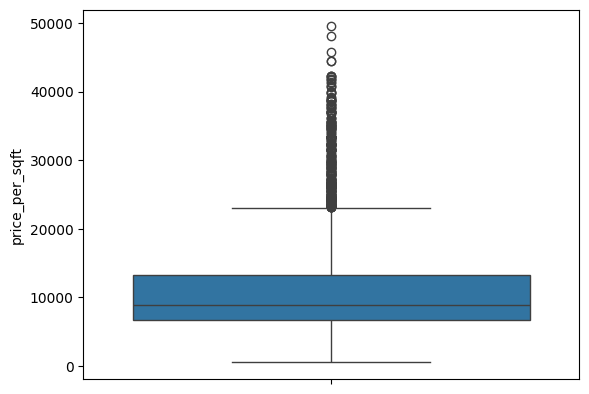

In [106]:
sns.boxplot(df['price_per_sqft'])

In [107]:
df[df['price_per_sqft'] > 42000]

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
711,house,sector 26,20.0,44444.0,4500.0,5,7,3+,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,unfurnished,Mid Floor,Medium
901,house,sector 28,12.0,42194.0,2844.0,4,5,3+,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,furnished,Mid Floor,Medium
1090,house,sector 105,9.9,49500.0,2000.0,2,2,2,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,semifurnished,Mid Floor,Low
1509,house,sector 55,5.0,44444.0,1125.0,9,9,3+,East,New Property,NaN,115.0,100.0,0,0,0,0,1,furnished,Mid Floor,Low
1526,house,sector 26,19.0,42054.0,4518.0,6,6,3,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,furnished,Low Floor,Medium
2040,house,sector 43,9.5,42222.0,2250.0,5,5,3+,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,furnished,Low Floor,Medium
2130,house,sector 26,19.0,42222.0,4500.0,6,8,3+,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,furnished,Mid Floor,Medium
3054,house,sector 43,13.0,48148.0,2700.0,3,3,3+,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,furnished,Mid Floor,Low
3108,house,sector 25,13.0,45710.0,2844.0,6,8,3+,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,unfurnished,NaN,Low


<br>

#### **<span style="color:black">- There is an issue with the 'area' & 'bedRoom' feature</span>**

In [110]:
x = df[df['price_per_sqft'] <= 20000]           # Focus only on normal/typical homes
(x['area']/x['bedRoom']).quantile(0.05)         # Basic Ratio --> According to area per bedroom 

np.float64(259.5)

In normal flat/houses, 95% have at least ~259 sqft per bedroom<br>
and only Bottom 5% smallest values


<br>

##### **<span style="color:black">i. Detect unrealistic cases</span>**

In [109]:
df[(df['area']/df['bedRoom'])<250]              # Bedrooms are too many for the given area

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
9,house,sector 105,1.20,10118.0,1186.0,6,2,1,North-West,Old Property,NaN,1185.51,NaN,0,0,0,0,0,semifurnished,Low Floor,Low
15,house,sector 12,1.20,14184.0,846.0,4,4,2,North,Relatively New,NaN,846.00,NaN,0,0,0,1,0,furnished,Low Floor,Low
37,house,sector 104,0.45,12162.0,370.0,4,4,2,North,Moderately Old,NaN,NaN,1500.0,0,0,0,0,0,furnished,Mid Floor,Low
48,house,sector 13,1.25,12077.0,1035.0,10,6,2,South-East,Old Property,NaN,115.00,NaN,0,0,0,0,1,semifurnished,Mid Floor,Low
74,house,sector 25,7.60,38756.0,1961.0,9,9,3,East,Relatively New,NaN,1935.00,NaN,1,0,1,1,0,furnished,Mid Floor,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3686,house,sector 12,0.90,13333.0,675.0,4,4,0,NaN,Undefined,NaN,675.00,NaN,0,0,0,0,0,semifurnished,Low Floor,Low
3713,house,sector 41,4.25,26235.0,1620.0,10,9,3+,North,Moderately Old,NaN,1620.00,NaN,1,1,0,0,0,furnished,Mid Floor,Low
3738,house,sector 7,1.16,11694.0,992.0,5,4,2,North-East,Moderately Old,NaN,NaN,992.0,0,0,0,0,1,semifurnished,Mid Floor,Low
3751,house,sector 21,0.45,8411.0,535.0,3,2,1,NaN,Undefined,NaN,NaN,535.0,0,0,0,0,0,semifurnished,Low Floor,Low


<br>

##### **<span style="color:black">ii. Visualizing Relationship & Creating Feature</span>**

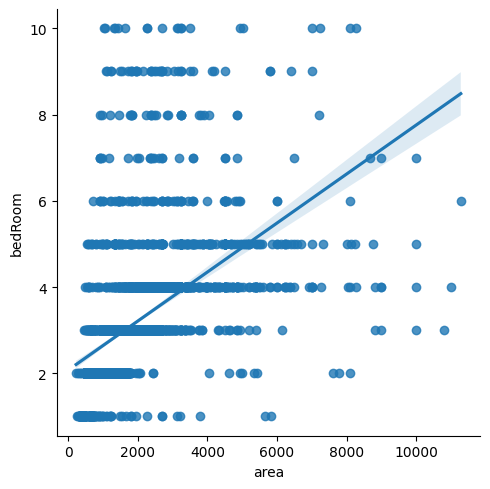

In [113]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [114]:
df['area_room_ratio'] = df['area'] / df['bedRoom']

<br>

##### **<span style="color:black">iii. Inspecting and Removing Extreme Cases</span>**

In [115]:
# Inspect low ratio cases
(df[df['area_room_ratio'] < 250])['bedRoom'].value_counts()     

bedRoom
2     45
3     31
5     18
6     16
9     15
4     11
8      9
10     8
7      6
Name: count, dtype: int64

In [116]:
# Remove extremely unrealistic entries
df = df[df['area_room_ratio'] > 100]

<br>

##### **<span style="color:black">iv. Identifying and Fixing Suspicious Data</span>**

In [129]:
df['area_room_ratio'] = df['area'] / df['bedRoom']

df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)].shape

(72, 22)

In [132]:
df = df[~((df['area_room_ratio'] < 250) & (df['bedRoom'] > 4))]

<br>

##### **<span style="color:black">v. Post Outlier Visualization</span>**

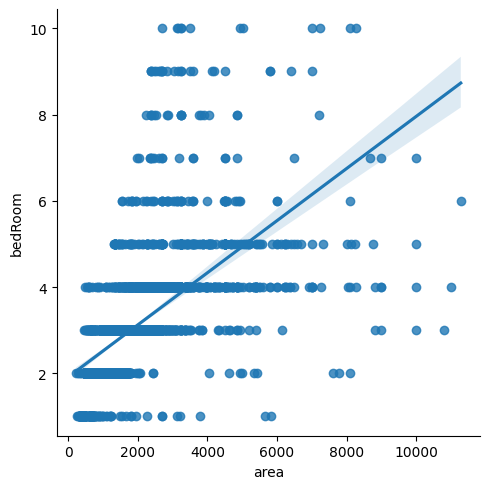

In [133]:
sns.lmplot(data=df, x='area', y='bedRoom')

<br>

## **<span style="color:black">- Saving Dataset</span>**

In [135]:
df.shape   # 3556

(3498, 22)

In [ ]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)  